# Multiple Linear Regression — Insurance Charges Prediction

This notebook documents a practical Machine Learning workflow using Python. It covers data understanding, missing-value handling, exploratory analysis, duplicate checks, outlier treatment using the IQR method, multicollinearity analysis with VIF, feature selection, train-test splitting, Linear Regression model training, prediction, error analysis, and R² evaluation.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Statsmodels

**Learning goal:** understand the complete journey from raw data to a trained Linear Regression model and evaluate its predictions.


**Dataset link**: https://drive.google.com/file/d/1Uzz8t8IbCoGCSNadaLe0fkZX6efU8WC6/view?usp=sharing

**Linear Regression is a Machine Learning algorithm used to model the relationship between a target variable and one or more independent variables.**


**It helps us understand how the target changes in relation to the input variables.**

**For example**:

**if you study more, you may get higher marks**

**This illustrates a simple linear relationship between study time and marks.**


**step1** Importing the libraries

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
insurance = pd.read_csv('/content/insurance_data.csv')

In [ ]:
insurance

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [ ]:
# Inspect the first five rows
insurance.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [ ]:
insurance.tail()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,170380500.5,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,201515184.8,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,223644981.3,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,252892382.6,3.0,4.006359e+09,southeast,62592.87309
1337,54.0,female,47.410,0.0,yes,63982.80926,31.0,1100328.0,261631699.3,3.0,4.117197e+09,southeast,63770.42801


In [ ]:
# Check dataset dimensions
insurance.shape

(1338, 13)

In [ ]:
# Inspect dataset information and data types
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [ ]:
insurance.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [ ]:
# object ->mode

# numerical -> mean . median

In [ ]:
col =list(insurance.columns)

In [ ]:
col

['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'Claim_Amount',
 'past_consultations',
 'num_of_steps',
 'Hospital_expenditure',
 'NUmber_of_past_hospitalizations',
 'Anual_Salary',
 'region',
 'charges']

In [ ]:
insurance['smoker'].mode()[0]

'no'

In [ ]:
for col_name in col:
  if insurance[col_name].dtypes == 'object':
    insurance[col_name] = insurance[col_name].fillna(insurance[col_name].mode()[0])

  else:
    insurance[col_name] = insurance[col_name].fillna(insurance[col_name].mean())


In [ ]:
insurance.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


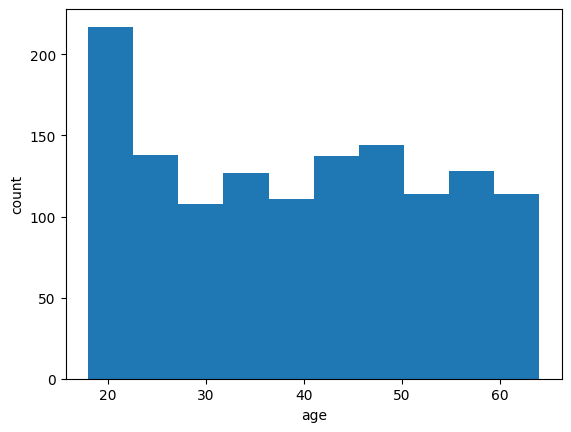

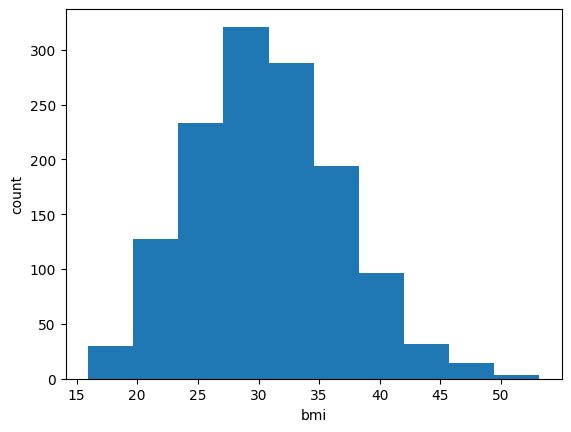

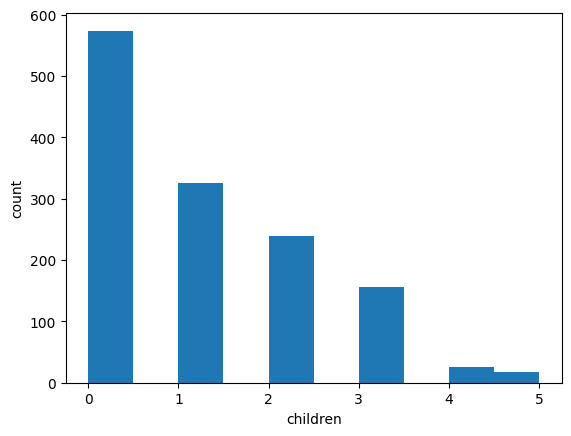

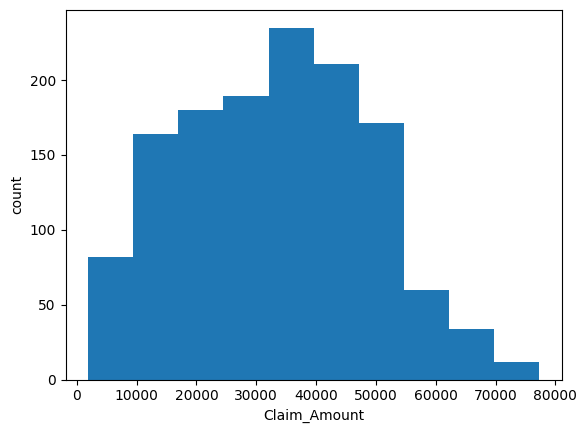

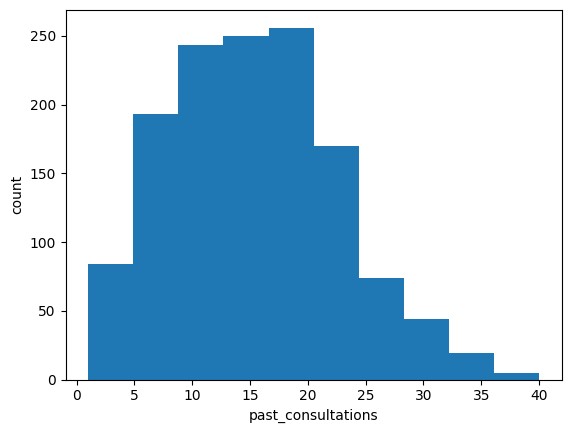

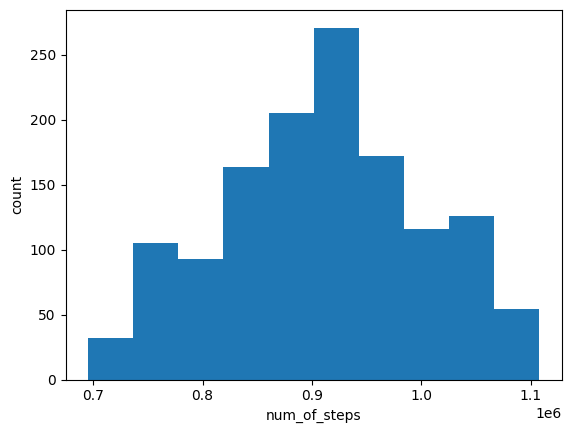

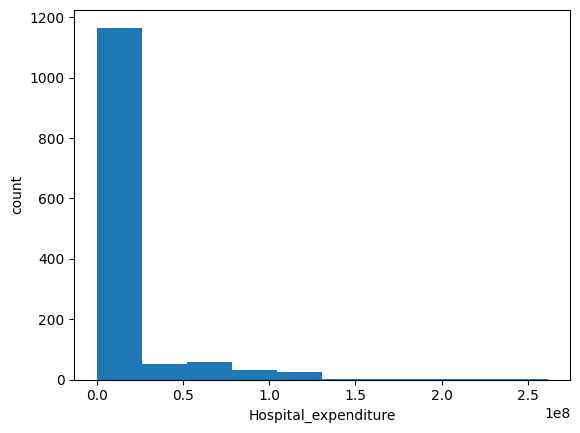

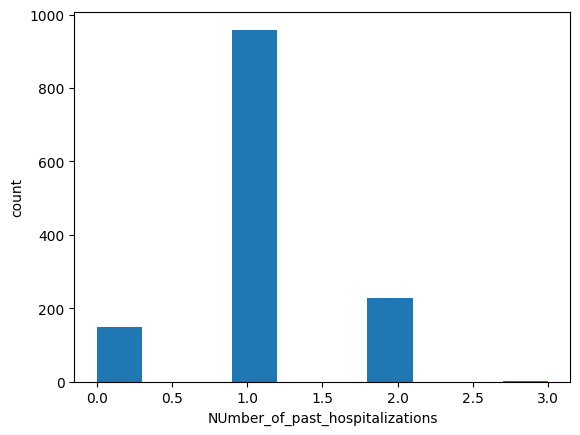

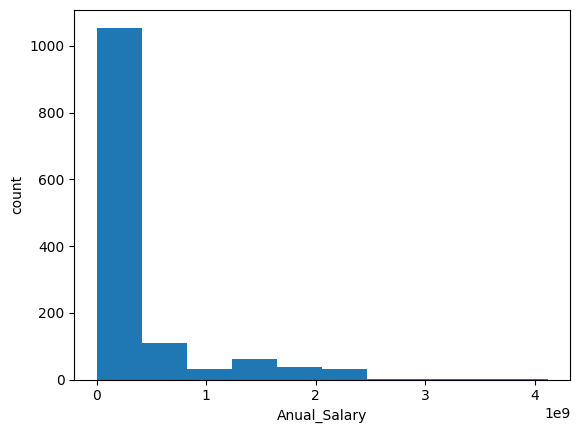

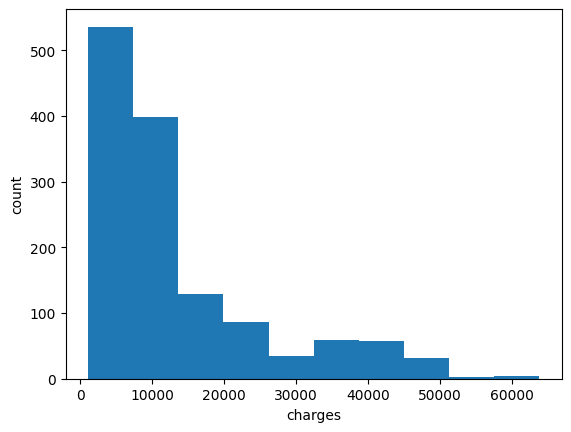

In [ ]:
# Explore numerical distributions

for col_name in col:
  if(insurance[col_name].dtypes =='int' or insurance[col_name].dtypes =='float'):
    plt.hist(insurance[col_name])
    plt.xlabel(col_name)
    plt.ylabel('count')
    plt.show()

In [ ]:
insurance.duplicated().sum()

np.int64(0)

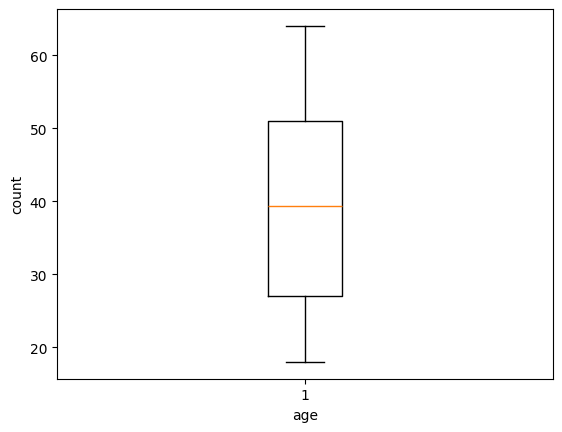

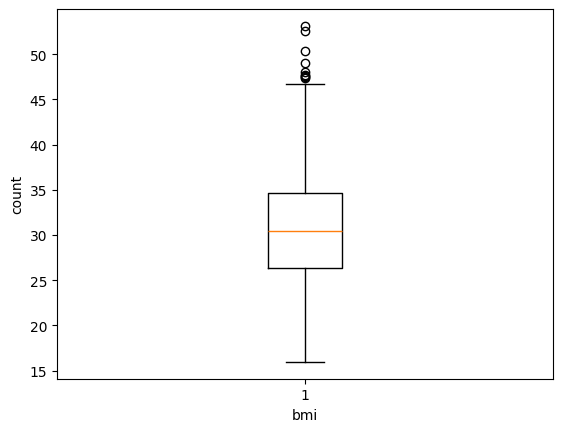

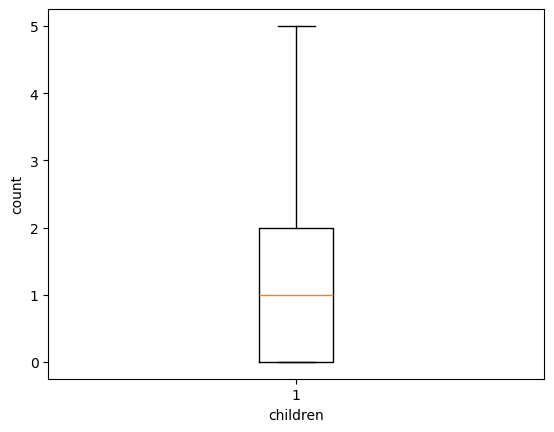

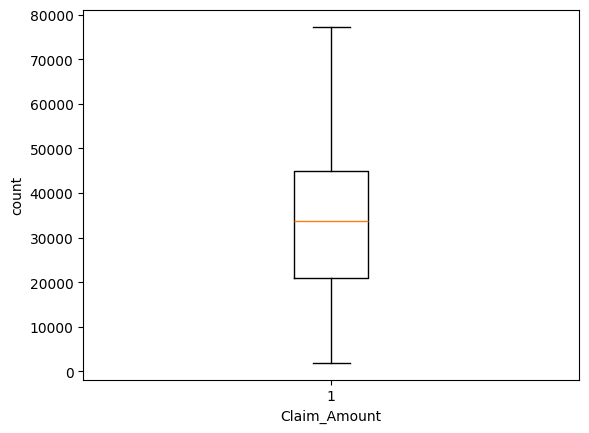

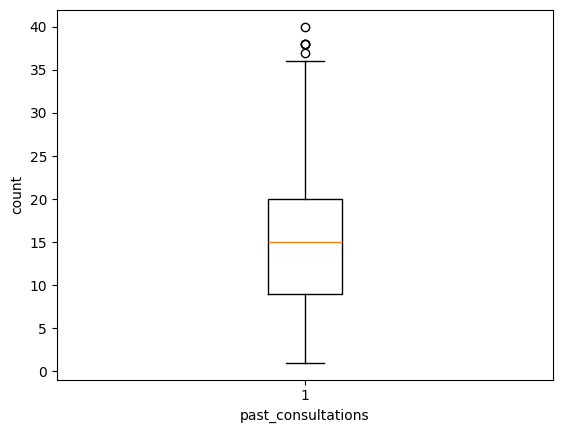

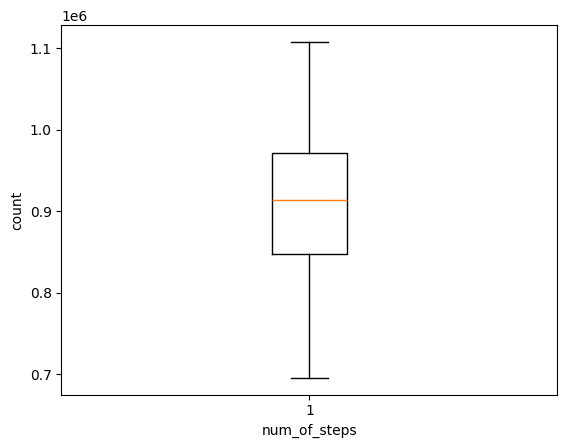

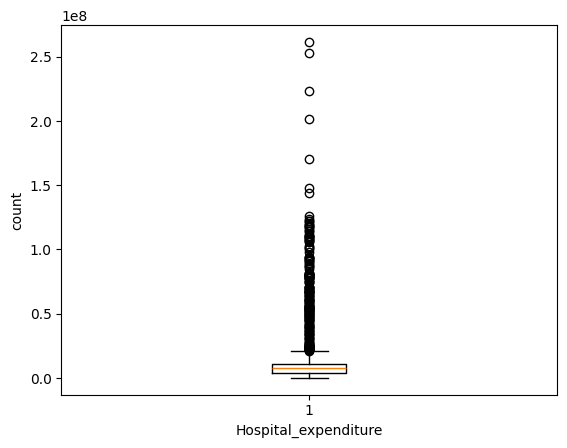

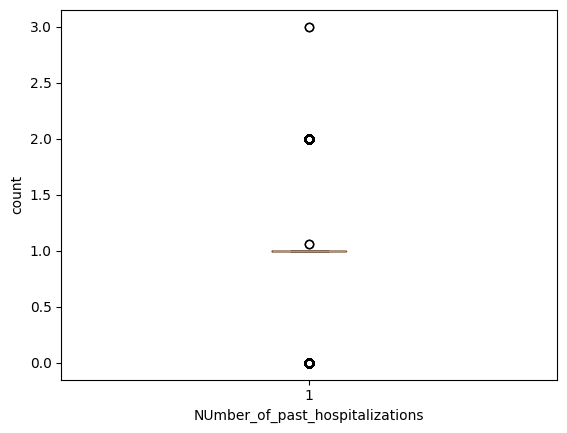

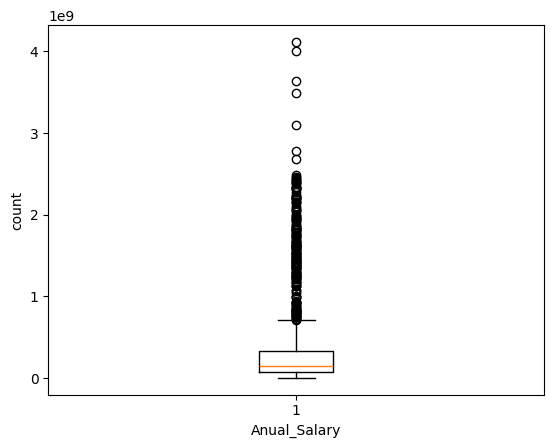

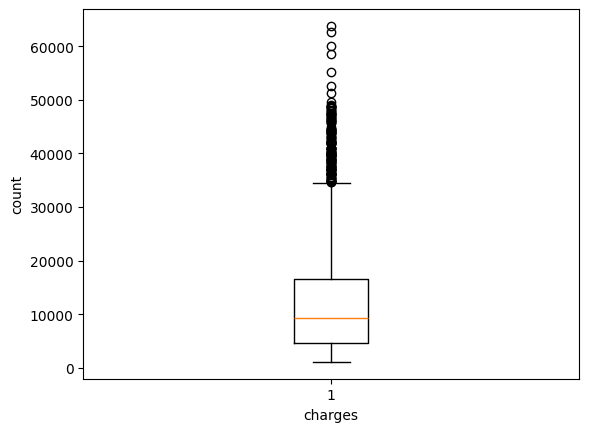

In [ ]:
for col_name in col:
  if(insurance[col_name].dtypes =='int' or insurance[col_name].dtypes =='float'):
    plt.boxplot(insurance[col_name])
    plt.xlabel(col_name)
    plt.ylabel('count')
    plt.show()

In [ ]:
#q1
# q3
# iqr
# lower bound and upper bound

Q1 = insurance.bmi.quantile(0.25)
Q3 = insurance.bmi.quantile(0.75)



In [ ]:
Q1

np.float64(26.315)

In [ ]:
Q3

np.float64(34.65625)

In [ ]:
IQR = Q3-Q1
IQR

np.float64(8.341249999999999)

In [ ]:
# lower limit

Q1 -1.5*IQR

np.float64(13.803125000000003)

In [ ]:
#UPPER LIMIT

Q3+1.5*IQR

np.float64(47.168124999999996)

In [ ]:

Q1 = insurance.bmi.quantile(0.25)
Q3 = insurance.bmi.quantile(0.75)
IQR = Q3-Q1
insurance = insurance[(insurance.bmi >=Q1 -1.5*IQR) &( insurance.bmi<=Q3+1.5*IQR)]

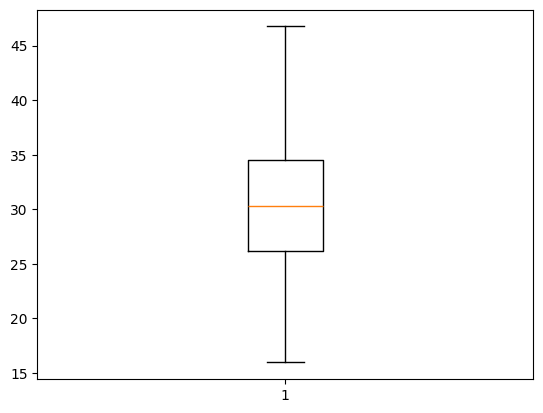

In [ ]:
plt.boxplot(insurance['bmi'])
plt.show()

In [ ]:

Q1 = insurance.past_consultations.quantile(0.25)
Q3 = insurance.past_consultations.quantile(0.75)
IQR = Q3-Q1
insurance = insurance[(insurance.past_consultations >=Q1 -1.5*IQR) &( insurance.past_consultations<=Q3+1.5*IQR)]




Q1 = insurance.Hospital_expenditure.quantile(0.25)
Q3 = insurance.Hospital_expenditure.quantile(0.75)
IQR = Q3-Q1
insurance = insurance[(insurance.Hospital_expenditure >=Q1 -1.5*IQR) &( insurance.Hospital_expenditure<=Q3+1.5*IQR)]




Q1 = insurance.Anual_Salary.quantile(0.25)
Q3 = insurance.Anual_Salary.quantile(0.75)
IQR = Q3-Q1
insurance = insurance[(insurance.Anual_Salary >=Q1 -1.5*IQR) &( insurance.Anual_Salary<=Q3+1.5*IQR)]

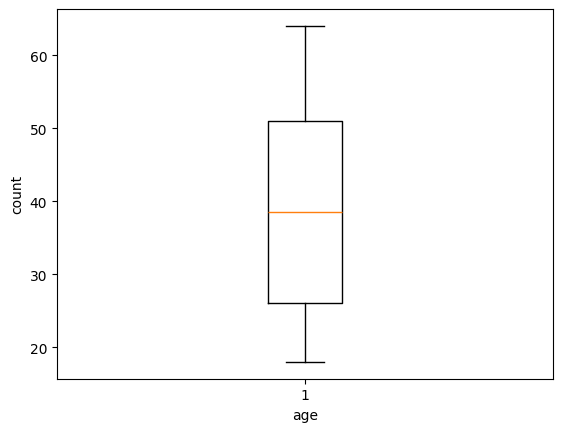

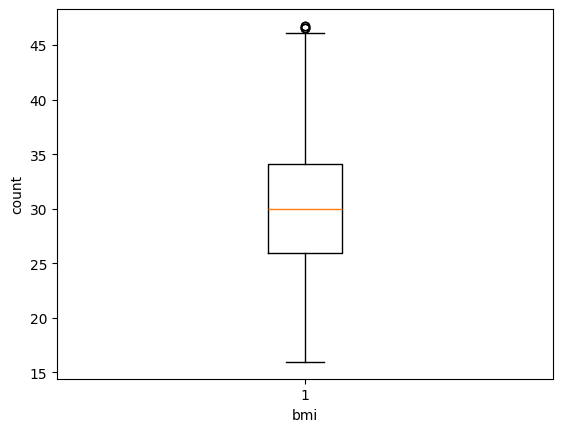

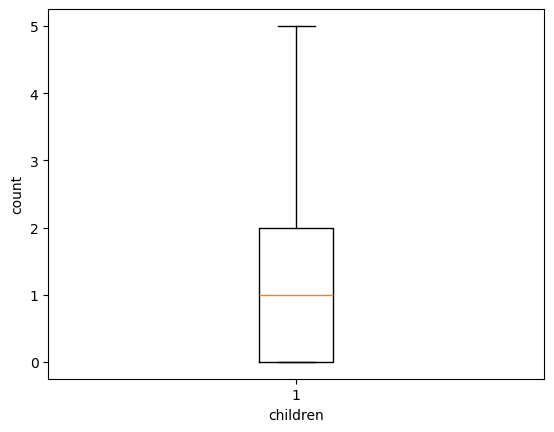

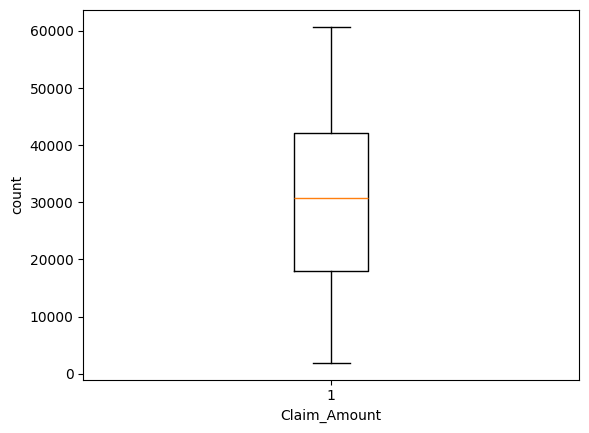

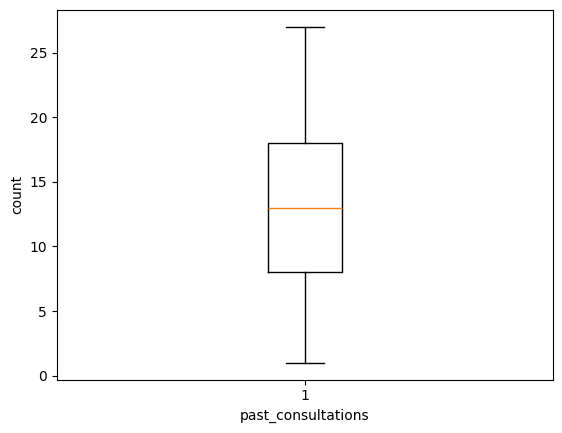

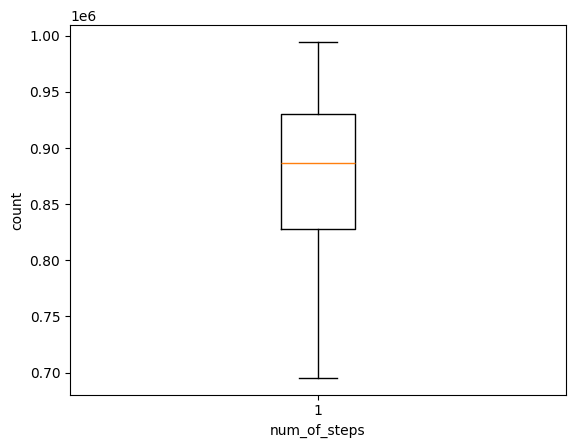

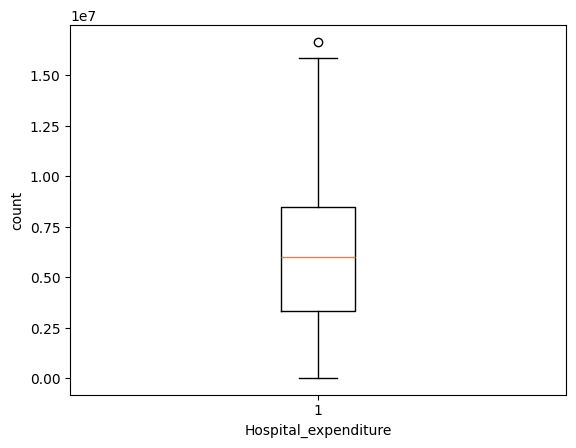

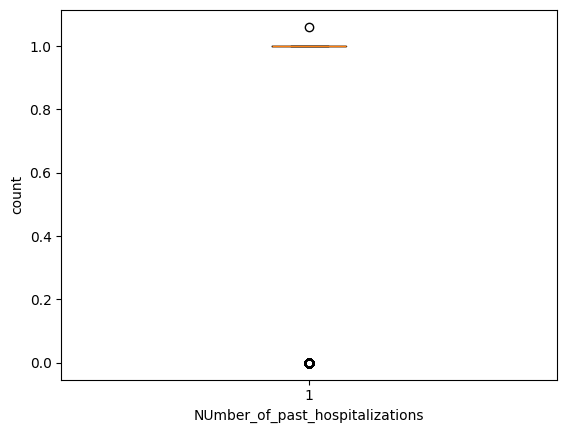

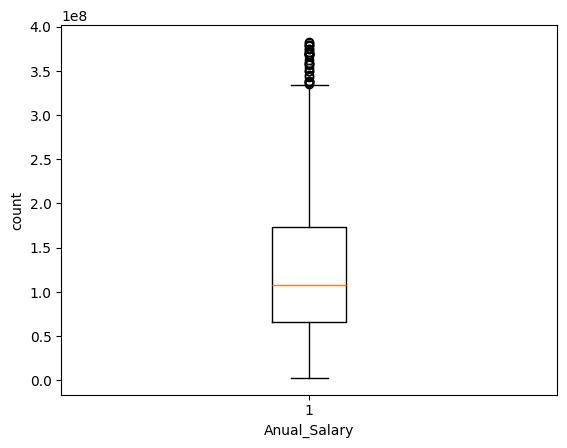

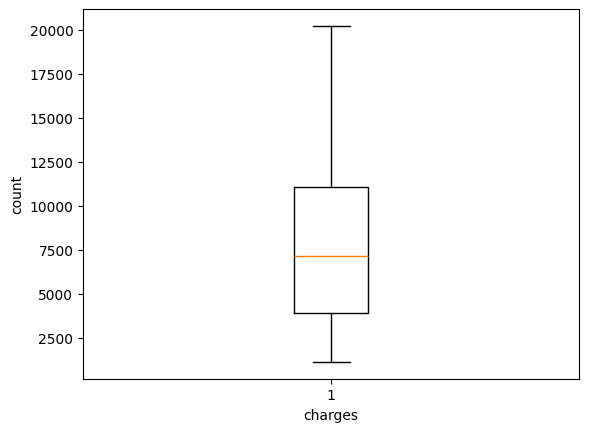

In [ ]:
for col_name in col:
  if(insurance[col_name].dtypes =='int' or insurance[col_name].dtypes =='float'):
    plt.boxplot(insurance[col_name])
    plt.xlabel(col_name)
    plt.ylabel('count')
    plt.show()

In [ ]:
insurance.shape

(1030, 13)

In [ ]:
"""
for i in df.columns:
  if df[i].dtypes=='int64' or df[i].dtypes=='float64':
    Q1=df[i].quantile(0.25)
    Q3=df[i].quantile(0.75)
    IQR=Q3-Q1
    LL=Q1-1.5*IQR
    UL=Q3+1.5*IQR
    df=df[(df[i]>=LL) & (df[i]<=UL)]"""

"\nfor i in df.columns:\n  if df[i].dtypes=='int64' or df[i].dtypes=='float64':\n    Q1=df[i].quantile(0.25)\n    Q3=df[i].quantile(0.75)\n    IQR=Q3-Q1\n    LL=Q1-1.5*IQR\n    UL=Q3+1.5*IQR\n    df=df[(df[i]>=LL) & (df[i]<=UL)]"

In [ ]:


"""for col_name in col:
  count=0
  if insurance[col_name].dtypes!='object':
    q1=insurance[col_name].quantile(0.25)
    q3=insurance[col_name].quantile(0.75)
    iqr=q3-q1
    lb=q1-1.5*iqr
    up=q3+1.5*iqr
    outliers = insurance[(insurance[col_name] < lb) | (insurance[col_name] > up)]
    count = outliers[col_name].count()
    print(col_name,count,'is the amount of outliers in the column') """

"for col_name in col:\n  count=0\n  if insurance[col_name].dtypes!='object':\n    q1=insurance[col_name].quantile(0.25)\n    q3=insurance[col_name].quantile(0.75)\n    iqr=q3-q1\n    lb=q1-1.5*iqr\n    up=q3+1.5*iqr\n    outliers = insurance[(insurance[col_name] < lb) | (insurance[col_name] > up)]\n    count = outliers[col_name].count()\n    print(col_name,count,'is the amount of outliers in the column') "

## Why Do We Need VIF?

When building Multiple Linear Regression, we use multiple independent variables to predict one target variable.

Sometimes two or more independent variables are highly correlated with each other. This can make coefficient interpretation less reliable because the variables may contain overlapping information.

**VIF (Variance Inflation Factor)** is used to detect multicollinearity between independent variables.

- **VIF = 1:** no multicollinearity
- **VIF between 1 and 5:** generally acceptable
- **VIF > 5:** investigate high multicollinearity


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
col_list =[]
for col in insurance.columns:
  if((insurance[col].dtypes !='object')& (col != 'charges')):
    col_list.append(col)

In [ ]:
col_list

['age',
 'bmi',
 'children',
 'Claim_Amount',
 'past_consultations',
 'num_of_steps',
 'Hospital_expenditure',
 'NUmber_of_past_hospitalizations',
 'Anual_Salary']

In [ ]:
X = insurance[col_list]
vif_data  = pd.DataFrame()
vif_data['Features'] = X.columns

vif_data['VIF'] = [variance_inflation_factor(X.values, i)  for i in range(len(X.columns))]


In [ ]:
print(vif_data)

                          Features        VIF
0                              age  15.452095
1                              bmi  26.330788
2                         children   2.029618
3                     Claim_Amount   5.678660
4               past_consultations   6.258017
5                     num_of_steps  61.574692
6             Hospital_expenditure   5.204376
7  NUmber_of_past_hospitalizations  12.052060
8                     Anual_Salary   5.481823


In [ ]:
insurance = insurance.drop(['num_of_steps'], axis=1)

In [ ]:
insurance

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,female,27.940,1.0,yes,51168.25474,23.0,1.665982e+07,1.0,3.712188e+08,southeast,19107.77960
1048,31.0,male,25.900,3.0,yes,46619.40230,27.0,1.361938e+07,1.0,3.812895e+08,southwest,19199.94400
1050,31.0,male,29.810,0.0,yes,24382.58056,21.0,1.028991e+07,1.0,3.745310e+08,southeast,19350.36890
1062,43.0,female,20.045,2.0,yes,21596.43846,10.0,1.083030e+07,1.0,3.696849e+08,northeast,19798.05455


In [ ]:
col_list =[]
for col in insurance.columns:
  if((insurance[col].dtypes !='object')& (col != 'charges')):
    col_list.append(col)

In [ ]:
X = insurance[col_list]
vif_data  = pd.DataFrame()
vif_data['Features'] = X.columns

vif_data['VIF'] = [variance_inflation_factor(X.values, i)  for i in range(len(X.columns))]


In [ ]:
print(vif_data)

                          Features        VIF
0                              age  14.484893
1                              bmi  12.261123
2                         children   2.017441
3                     Claim_Amount   5.243640
4               past_consultations   5.842169
5             Hospital_expenditure   4.929952
6  NUmber_of_past_hospitalizations  10.687768
7                     Anual_Salary   5.380679


In [ ]:
insurance = insurance.drop(['age'], axis =1)

In [ ]:
col_list =[]
for col in insurance.columns:
  if((insurance[col].dtypes !='object')& (col != 'charges')):
    col_list.append(col)

In [ ]:
X = insurance[col_list]
vif_data  = pd.DataFrame()
vif_data['Features'] = X.columns

vif_data['VIF'] = [variance_inflation_factor(X.values, i)  for i in range(len(X.columns))]


In [ ]:
print(vif_data)

                          Features        VIF
0                              bmi  10.323093
1                         children   1.978843
2                     Claim_Amount   5.228284
3               past_consultations   5.821933
4             Hospital_expenditure   4.929287
5  NUmber_of_past_hospitalizations   8.310570
6                     Anual_Salary   4.723495


In [ ]:
insurance = insurance.drop(['bmi'], axis=1)

In [ ]:
col_list =[]
for col in insurance.columns:
  if((insurance[col].dtypes !='object')& (col != 'charges')):
    col_list.append(col)

In [ ]:
X = insurance[col_list]
vif_data  = pd.DataFrame()
vif_data['Features'] = X.columns

vif_data['VIF'] = [variance_inflation_factor(X.values, i)  for i in range(len(X.columns))]


In [ ]:
vif_data

,Features,VIF
0,children,1.977037
1,Claim_Amount,4.547332
2,past_consultations,5.049165
3,Hospital_expenditure,4.492630
4,NUmber_of_past_hospitalizations,7.245972
5,Anual_Salary,4.688833


In [ ]:
insurance = insurance.drop(['NUmber_of_past_hospitalizations'] , axis =1)

In [ ]:
col_list =[]
for col in insurance.columns:
  if((insurance[col].dtypes !='object')& (col != 'charges')):
    col_list.append(col)

In [ ]:
X = insurance[col_list]
vif_data  = pd.DataFrame()
vif_data['Features'] = X.columns

vif_data['VIF'] = [variance_inflation_factor(X.values, i)  for i in range(len(X.columns))]


In [ ]:
vif_data

,Features,VIF
0,children,1.713101
1,Claim_Amount,4.152224
2,past_consultations,4.670212
3,Hospital_expenditure,4.320876
4,Anual_Salary,4.279483


In [ ]:
x = insurance.loc[:, ["children","Claim_Amount","past_consultations","Hospital_expenditure","Anual_Salary"]]
y= insurance.iloc[:, -1]

In [ ]:
"""def calculate_vif_from_df(df, target_col):
 col_list =[]
 for col in insurance.columns:
   if((insurance[col].dtypes !='object')& (col != 'charges')):
     col_list.append(col)

 X  = insurance[col_list]
 vif_data  = pd.DataFrame()
 vif_data['Features'] = X.columns

 vif_data['VIF'] = [variance_inflation_factor(X.values, i)
 for i in range(len(X.columns))]
 return vif_data


vif_result =calculate_vif_from_df(insurance, 'charges')

print(vif_result)"""



In [ ]:
x

,children,Claim_Amount,past_consultations,Hospital_expenditure,Anual_Salary
0,0.0,29087.54313,17.0,4.720921e+06,5.578497e+07
1,0.0,39053.67437,7.0,4.329832e+06,1.370089e+07
2,0.0,39023.62759,19.0,6.884861e+06,7.352311e+07
3,0.0,28185.39332,11.0,4.274774e+06,7.581968e+07
4,0.0,14697.85941,16.0,3.787294e+06,2.301232e+07
...,...,...,...,...,...
1046,1.0,51168.25474,23.0,1.665982e+07,3.712188e+08
1048,3.0,46619.40230,27.0,1.361938e+07,3.812895e+08
1050,0.0,24382.58056,21.0,1.028991e+07,3.745310e+08
1062,2.0,21596.43846,10.0,1.083030e+07,3.696849e+08


In [ ]:
y

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1046,19107.77960
1048,19199.94400
1050,19350.36890
1062,19798.05455


In [ ]:
# Train-test split: 80% training data and 20% test data

# 80% training data and 20% test data
# x_train/y_train → model training; x_test/y_test → evaluation
# x_train and y_train are used to train the model
# x_test is used for testing and comparison with y_test
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.8 , random_state = 0)
# random_state ensures reproducible splitting


In [ ]:
x_train

,children,Claim_Amount,past_consultations,Hospital_expenditure,Anual_Salary
746,0.0,25238.363470,11.0,2.086869e+06,1.649883e+08
641,0.0,37222.476360,9.0,6.062378e+06,9.657123e+07
999,1.0,30825.190070,11.0,5.923489e+06,3.029514e+08
281,0.0,9560.754493,15.0,3.185350e+06,7.490390e+07
802,2.0,12992.139950,24.0,4.075903e+06,2.061268e+08
...,...,...,...,...,...
279,1.0,20150.675120,9.0,1.747107e+05,6.328892e+07
768,0.0,9582.708574,11.0,1.046259e+07,1.850292e+08
841,0.0,31405.793590,12.0,9.380141e+06,2.118739e+08
561,2.0,9816.604000,12.0,8.134594e+05,1.287152e+08


In [ ]:
y_train

,charges
746,10594.50155
641,8932.08400
999,16450.89470
281,4185.09790
802,11396.90020
...,...
279,4149.73600
768,10965.44600
841,11938.25595
561,7740.33700


In [ ]:
l_model = LinearRegression()

In [ ]:
l_model.fit(x_train, y_train) # Train the Linear Regression model

LinearRegression()

In [ ]:
prediction = l_model.predict(x_test)

In [ ]:
prediction

array([ 7410.79368291, 10525.46032916,  4225.68186835, 11784.67064226,
        9710.4476994 ,  2920.28422478,  7675.02920952,  3974.05235591,
        1998.9072971 ,  1644.33779822,  9355.99422157,  6212.23827285,
        7039.69058407,  6913.4106462 ,  7297.05052728,  8116.21854336,
        5359.21098612, 11610.94654975, 10731.85265307,  4125.98535047,
        4978.27582416,  7076.11959566,  5297.22536169, 10517.54532015,
        7970.3230254 ,  9134.27913298,  3195.07752334,  2030.84851755,
        7974.53183189,  6784.2193549 ,  9063.13892275,  9603.83277347,
        7310.54589069,  3127.0522965 , 10815.26325585,  6390.86195986,
        2959.61224856,  5861.07915274,  8191.7821509 ,  3550.84253838,
        2770.66188065,  7533.68996883,  9234.0016588 ,  4599.21923178,
        7080.45812908,  6040.26489712,  9148.59452641,  9621.34374206,
        1845.77904492,  4786.94915211, 10787.39907087, 10725.71531504,
       10417.07991618,  4695.22528892,  7214.06291724,  4625.56717867,
      

In [ ]:
error_pred = pd.DataFrame(columns =['Actual DATA', 'Prediction DATA'])

In [ ]:
error_pred['Actual DATA'] = y_test

In [ ]:
error_pred

,Actual DATA,Prediction DATA
752,10704.47000,NaN
723,10197.77220,NaN
177,2801.25880,NaN
834,11848.14100,NaN
718,10107.22060,NaN
...,...,...
627,8688.85885,NaN
993,16085.12750,NaN
426,5976.83110,NaN
895,12925.88600,NaN


In [ ]:
error_pred['Prediction DATA'] = prediction

In [ ]:
error_pred

,Actual DATA,Prediction DATA
752,10704.47000,7410.793683
723,10197.77220,10525.460329
177,2801.25880,4225.681868
834,11848.14100,11784.670642
718,10107.22060,9710.447699
...,...,...
627,8688.85885,5781.937583
993,16085.12750,14969.262737
426,5976.83110,4926.602197
895,12925.88600,11617.127211


In [ ]:
error_pred['error'] = error_pred['Actual DATA'] - error_pred['Prediction DATA']

In [ ]:
error_pred

,Actual DATA,Prediction DATA,error
752,10704.47000,7410.793683,3293.676317
723,10197.77220,10525.460329,-327.688129
177,2801.25880,4225.681868,-1424.423068
834,11848.14100,11784.670642,63.470358
718,10107.22060,9710.447699,396.772901
...,...,...,...
627,8688.85885,5781.937583,2906.921267
993,16085.12750,14969.262737,1115.864763
426,5976.83110,4926.602197,1050.228903
895,12925.88600,11617.127211,1308.758789


In [ ]:
from sklearn.metrics import *

In [ ]:
r2_square = r2_score(y_test, prediction)

In [ ]:
r2_square # R² score

0.8436003409637491

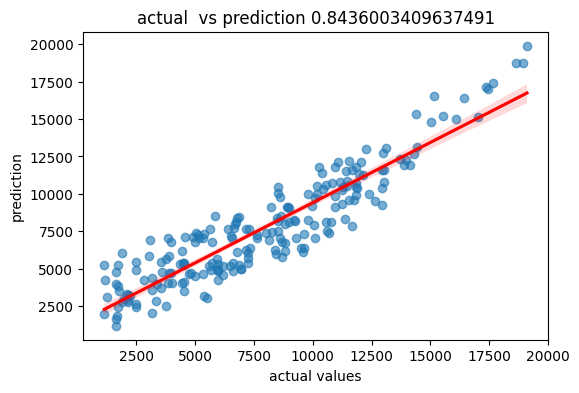

In [ ]:
plt.figure(figsize =(6,4))
sns.regplot(x = y_test, y= prediction, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('actual values')
plt.ylabel('prediction')
plt.title(f'actual  vs prediction { r2_square}')
plt.show()